In [2]:
import numpy as np
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
from numba import cuda

In [6]:
def matmul_cpu_implementation(A, B):
   # умножение матриц на CPU
    C = np.zeros((A.shape[0], B.shape[1]), dtype=np.float32)
    start_time = time.time()
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            temp_sum = 0.0
            for k in range(A.shape[1]):
                temp_sum += A[i, k] * B[k, j]
            C[i, j] = temp_sum
    end_time = time.time()
    return C, end_time - start_time

@cuda.jit
def cuda_kernel_matrix_multiply(A, B, C):
    # CUDA ядро для умножения матриц
    i, j = cuda.grid(2)
    if i < A.shape[0] and j < B.shape[1]:
        temp_sum = 0.0
        for k in range(A.shape[1]):
            temp_sum += A[i, k] * B[k, j]
        C[i, j] = temp_sum

def matmul_gpu_implementation(A, B):
    # умножение матриц на GPU
    A_device = cuda.to_device(A)
    B_device = cuda.to_device(B)
    C_device = cuda.device_array((A.shape[0], B.shape[1]), dtype=np.float32)

    threads_per_block = (16, 16)
    blocks_per_grid_x = math.ceil(A.shape[0] / threads_per_block[0])
    blocks_per_grid_y = math.ceil(B.shape[1] / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    start_time = time.time()
    cuda_kernel_matrix_multiply[blocks_per_grid, threads_per_block](A_device, B_device, C_device)
    cuda.synchronize()
    end_time = time.time()

    C = C_device.copy_to_host()
    return C, end_time - start_time

def check_correctness(C, C_ref):
    # проверка корректности умножения
    return np.allclose(C, C_ref, atol=1e-6)

In [7]:
matrix_sizes = [100, 200, 400, 800, 1600, 2000]
results = []

for size in matrix_sizes:
    print(f"\nРазмер матрицы: {size}x{size}")

    A = np.random.rand(size, size).astype(np.float32)
    B = np.random.rand(size, size).astype(np.float32)

    C_cpu, time_cpu = matmul_cpu_implementation(A, B)
    C_gpu, time_gpu = matmul_gpu_implementation(A, B)

    C_reference = np.dot(A, B)
    is_cpu_correct = check_correctness(C_cpu, C_reference)
    is_gpu_correct = check_correctness(C_gpu, C_reference)

    speedup = time_cpu / time_gpu if time_gpu > 0 else None

    results.append({
        'Размер': size,
        'Время CPU': round(time_cpu, 4),
        'Время GPU': round(time_gpu, 4),
        'Ускорение': round(speedup, 2) if speedup else None,
        'Корректность CPU': is_cpu_correct,
        'Корректность GPU': is_gpu_correct
    })

    print(f"  CPU: {time_cpu:.4f} сек")
    print(f"  GPU: {time_gpu:.4f} сек")
    print(f"  Ускорение: {speedup:.2f}x")


Размер матрицы: 100x100


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


  CPU: 0.3546 сек
  GPU: 0.1346 сек
  Ускорение: 2.63x

Размер матрицы: 200x200
  CPU: 2.9347 сек
  GPU: 0.0006 сек
  Ускорение: 4904.00x

Размер матрицы: 400x400
  CPU: 26.4676 сек
  GPU: 0.0034 сек
  Ускорение: 7828.84x

Размер матрицы: 800x800
  CPU: 206.9425 сек
  GPU: 0.0297 сек
  Ускорение: 6964.90x

Размер матрицы: 1600x1600
  CPU: 1677.4829 сек
  GPU: 0.2008 сек
  Ускорение: 8355.77x

Размер матрицы: 2000x2000
  CPU: 3399.3910 сек
  GPU: 0.3259 сек
  Ускорение: 10430.04x


 Размер  Время CPU  Время GPU  Ускорение  Корректность CPU  Корректность GPU
    100     0.3546     0.1346       2.63              True              True
    200     2.9347     0.0006    4904.00              True              True
    400    26.4676     0.0034    7828.84              True              True
    800   206.9425     0.0297    6964.90              True              True
   1600  1677.4829     0.2008    8355.77              True              True
   2000  3399.3910     0.3259   10430.04              True              True


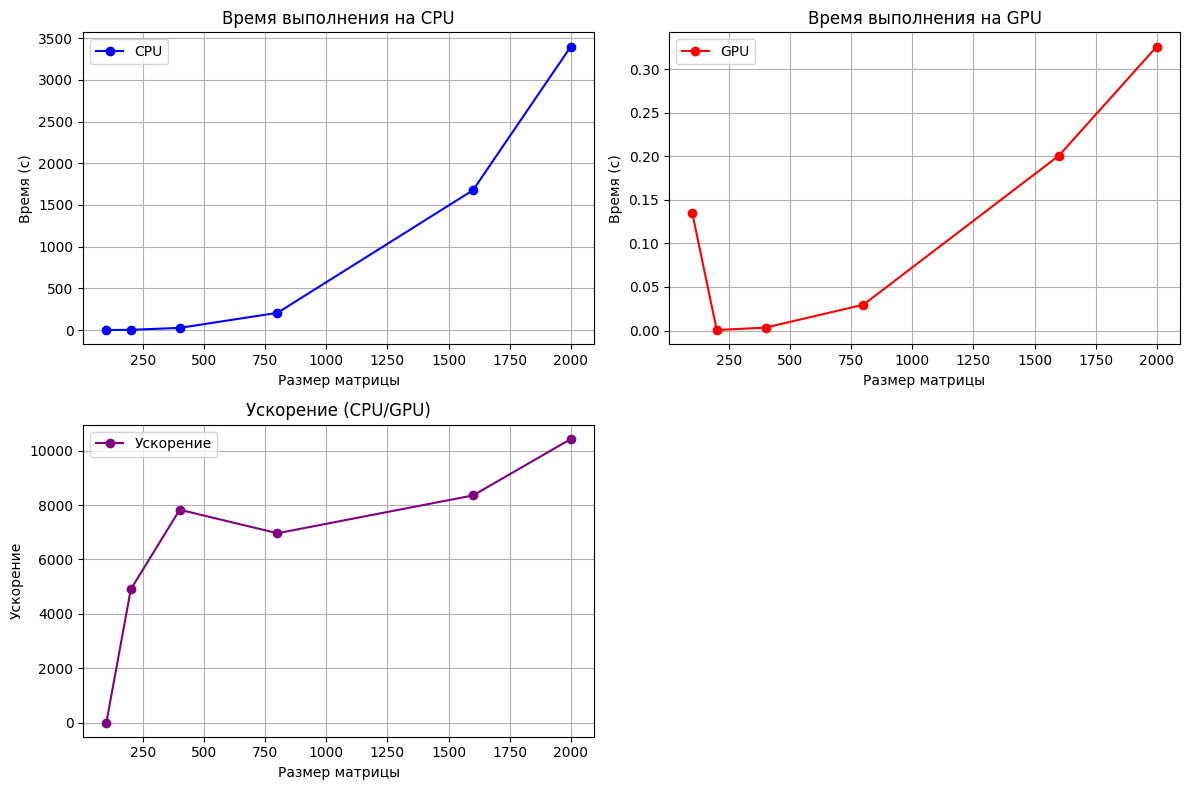

In [8]:
df = pd.DataFrame(results)
print(df.to_string(index=False))

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(df['Размер'], df['Время CPU'], label='CPU', marker='o', color='blue')
plt.xlabel('Размер матрицы')
plt.ylabel('Время (с)')
plt.title('Время выполнения на CPU')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(df['Размер'], df['Время GPU'], label='GPU', marker='o', color='red')
plt.xlabel('Размер матрицы')
plt.ylabel('Время (с)')
plt.title('Время выполнения на GPU')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(df['Размер'], df['Ускорение'], label='Ускорение', marker='o', color='purple')
plt.xlabel('Размер матрицы')
plt.ylabel('Ускорение')
plt.title('Ускорение (CPU/GPU)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()